# House Price Prediction using Machine Learning
This project predicts house prices using:
- Linear Regression
- polynomial regression
- L2 Regularization

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# create dataset

data = pd.DataFrame({'Size': [750, 800, 900, 1100, 1200, 1400, 1500, 1600, 1700, 1800], 'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 3, 4, 4], 'Price': [150000, 160000, 180000, 200000, 210000, 240000, 250000, 265000, 280000, 300000]})
print(data.head())

   Size  Bedrooms   Price
0   750         2  150000
1   800         2  160000
2   900         3  180000
3  1100         3  200000
4  1200         3  210000


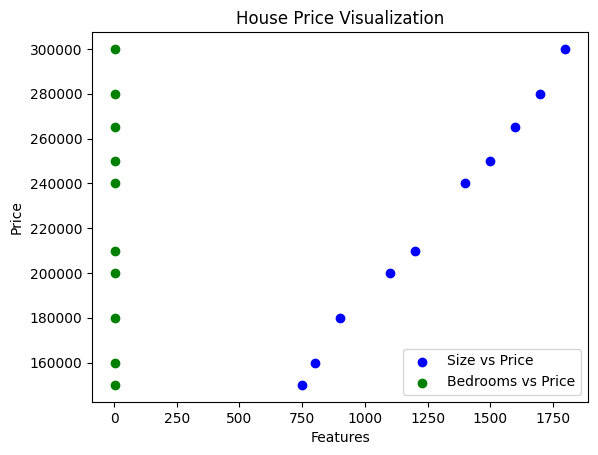

In [29]:
# Visualize data

plt.scatter(data['Size'], data['Price'], color='blue', label='Size vs Price')
plt.scatter(data['Bedrooms'], data['Price'], color='green', label='Bedrooms vs Price')
plt.xlabel("Features")
plt.ylabel("Price")
plt.title("House Price Visualization")
plt.legend()
plt.show()

In [30]:
# Linear Regression using Gradient Decent

# Prepare feature (Size, Bedrooms,) and target (Price)
x = data[['Size', 'Bedrooms']].values
y = data['Price'].values

# Initialize weight and bias to zero
w = np.zeros(x.shape[1])
b = 0.0

# Set learning parameters
lr = 0.000001
iterations = 5000

# Gradient Decent Loop
for i in range(iterations):
    y_pred = x @ w + b
    # compute predictions
    error = y_pred - y
    # compute error

    # compute gradients
    dw = (x.T @ error) / len(y)
    db = np.mean(error)

    # update weight and bias
    w -= lr * dw
    b -= lr * db

    # print loss every 500 iterations
    if i % 500 == 0:
        loss = np.mean(error**2)
        print(f"iteration {i}, loss: {loss:.2f}")

print("final weight:", w)
print("final bias:", b)

iteration 0, loss: 52332500000.00
iteration 500, loss: 212036199.62
iteration 1000, loss: 212005234.34
iteration 1500, loss: 211974275.94
iteration 2000, loss: 211943324.44
iteration 2500, loss: 211912379.82
iteration 3000, loss: 211881442.10
iteration 3500, loss: 211850511.25
iteration 4000, loss: 211819587.29
iteration 4500, loss: 211788670.21
final weight: [172.20613315  20.47902828]
final bias: 19.393477752585316


In [31]:
# Polynomial Regression (degree 2) with L2 Regularization

from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

# Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x) # Size, Bedrooms, Size^2, Size*Bedrooms, Bedrooms^2

# Scale feature to prevent large numbers
scaler = StandardScaler()
x_poly_scaled = scaler.fit_transform(x_poly)

# Initialize weight and bias
w = np.zeros(x_poly_scaled.shape[1])
b = 0.0

# Set learning parameters
lr = 0.01
iterations = 5000
lambda_reg = 0.01 # regularization strength

# Gradient Decent with L2 Regularization
for i in range(iterations):
    y_pred = x_poly_scaled @ w + b # compute predictions
    error = y_pred - y # compute error

    dw = (x_poly_scaled.T @ error) / len(y) + (lambda_reg * w) # Gradient with Regularization
    db = np.mean(error) # Gradient with bias

    # update weight and bias
    w -= lr * dw
    b -= lr * db

    # print loss every 500 iterations
    if i % 500 == 0:
        loss = np.mean(error**2) + (lambda_reg/2) * np.sum(w**2)
        print(f"iteration {i}, loss: {loss:.2f}")

print("Training complete")
print("Final weight:", w)
print("Final bias:", b)

iteration 0, loss: 52332505214.81
iteration 500, loss: 23297901.62
iteration 1000, loss: 15652100.13
iteration 1500, loss: 14954936.38
iteration 2000, loss: 14561037.02
iteration 2500, loss: 14246247.96
iteration 3000, loss: 13982428.87
iteration 3500, loss: 13758847.62
iteration 4000, loss: 13568416.38
iteration 4500, loss: 13405606.68
Training complete
Final weight: [21345.6487161   4963.76577554 19935.83866309  6890.80393327
 -4293.92316493]
Final bias: 223499.99999999857


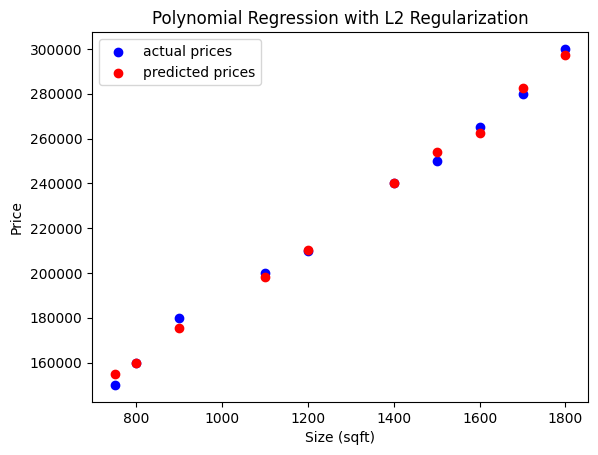

In [32]:
# Visualize Polynomial Regression Predictions

# Predict prices using trained polynomial model
y_p_poly = x_poly_scaled @ w + b

# Plot actual vs predicted
plt.scatter(data['Size'], y, color='blue', label='actual prices') # blue dots
plt.scatter(data['Size'], y_p_poly, color='red', label='predicted prices') # red dots

# Label and Title
plt.xlabel("Size (sqft)")
plt.ylabel("Price")
plt.title("Polynomial Regression with L2 Regularization")
plt.legend()
plt.show()